# **PUNTO 1**

# ##. Carga de la base de datos y chequeos rapidos

In [2]:
# ==============================================================================
# MÓDULO 1: Instalación e importación de librerías
# ==============================================================================
# Instalación silenciosa de dependencias (-q evita que se llene la pantalla de texto)
import sys
!{sys.executable} -m pip install -U ydata-profiling[notebook] -q
!jupyter nbextension enable --py widgetsnbextension -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ydata_profiling import ProfileReport
!pip install factor_analyzer -q

# Configuración de estilo visual de Seaborn
sns.set_theme(style="whitegrid")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 52.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 46.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.8/400.8 kB 30.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 85.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 120.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 915.3/915.3 kB 50.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.5/77.5 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 5.3 MB/s eta 0:00:00
usage: jupyter-nbextension [-h] [--debug] [--show-config] [--show-config-json]
                           [--user] [--system] [--

/tmp/ipykernel_1205/1314488421.py:13: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.8/42.8 kB 2.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [3]:
# ==============================================================================
# MÓDULO 2: Carga de la base de datos y chequeos iniciales
# ==============================================================================
url = 'https://raw.githubusercontent.com/brunolabarre-cmd/m1a4/refs/heads/main/Comparto-_base_empleados_-contigo.csv'
df_empleados = pd.read_csv(url)

# Renombrar columnas para evitar el uso de siglas y hacer el código legible
df_empleados.rename(columns={
    'dt': 'dias_trabajados',
    'w': 'salario',
    'dv': 'dias_vacaciones'
}, inplace=True)

# Visualizar las primeras filas y la información de los tipos de datos
display(df_empleados.head())
print("\n--- Información del Dataset ---")
df_empleados.info()

,edad,dias_trabajados,salario,dias_vacaciones
0,50,211,28748,18
1,36,233,38545,12
2,29,232,91199,28
3,42,247,59766,25
4,40,254,98530,25



--- Información del Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   edad             90 non-null     int64
 1   dias_trabajados  90 non-null     int64
 2   salario          90 non-null     int64
 3   dias_vacaciones  90 non-null     int64
dtypes: int64(4)
memory usage: 2.9 KB


# ##. analisis descriptivo y medidas univariado

In [4]:
# ==============================================================================
# MÓDULO 3: Análisis Descriptivo Univariado
# ==============================================================================
# Resumen estadístico general
display(df_empleados.describe())

print("\n--- Medidas de Tendencia Central (Mediana y Moda) ---")
for col in df_empleados.columns:
    mediana = df_empleados[col].median()
    moda = df_empleados[col].mode()[0]
    print(f"{col.capitalize():<18}: Mediana = {mediana:<8} | Moda = {moda}")

,edad,dias_trabajados,salario,dias_vacaciones
count,90.000000,90.000000,90.000000,90.000000
mean,39.044444,229.777778,75752.755556,19.444444
std,10.497631,16.958494,28444.424131,6.866481
min,22.000000,200.000000,25854.000000,10.000000
25%,29.250000,214.000000,51415.750000,12.000000
50%,39.000000,231.000000,76873.000000,18.500000
75%,46.750000,242.750000,98321.000000,26.000000
max,59.000000,260.000000,119209.000000,30.000000



--- Medidas de Tendencia Central (Mediana y Moda) ---
Edad              : Mediana = 39.0     | Moda = 29
Dias_trabajados   : Mediana = 231.0    | Moda = 238
Salario           : Mediana = 76873.0  | Moda = 25854
Dias_vacaciones   : Mediana = 18.5     | Moda = 12


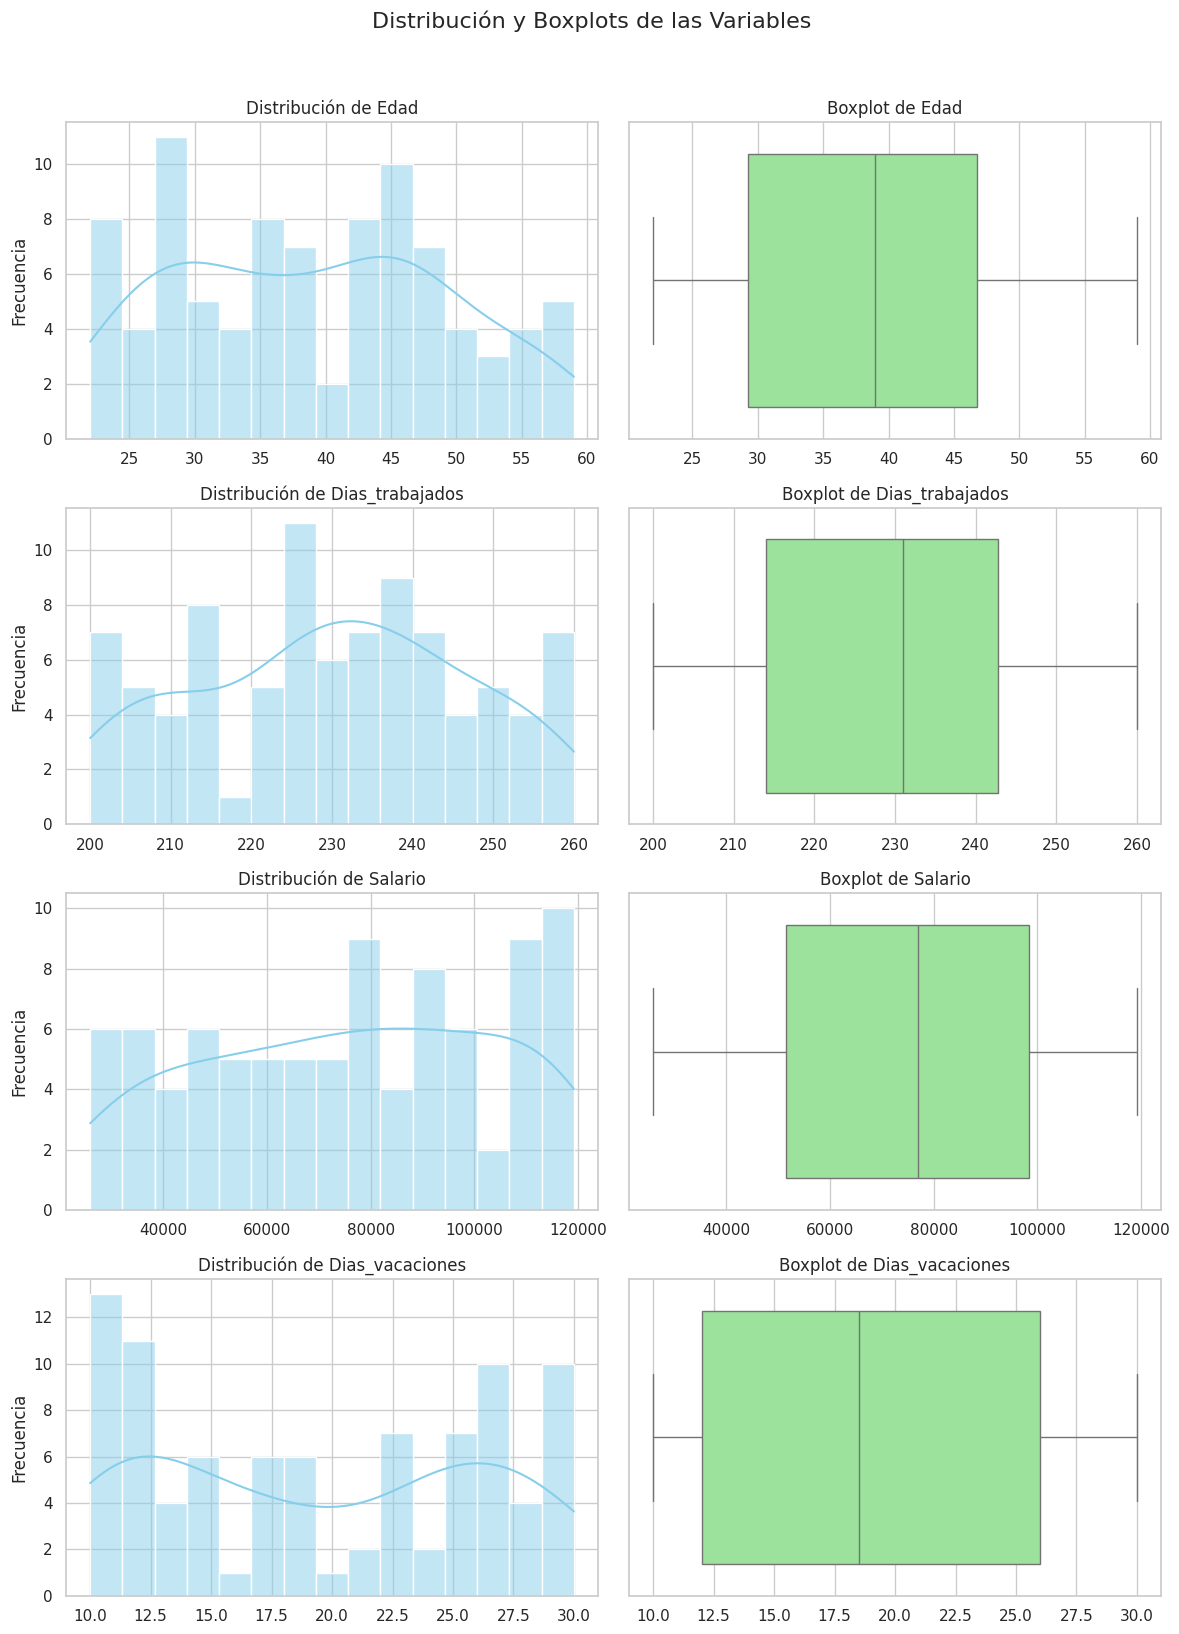

In [5]:
# ==============================================================================
# MÓDULO 4: Visualización de Distribuciones y Boxplots
# ==============================================================================
columnas = df_empleados.columns
fig, axes = plt.subplots(nrows=len(columnas), ncols=2, figsize=(12, 16))
fig.suptitle('Distribución y Boxplots de las Variables', fontsize=16, y=1.02)

for i, col in enumerate(columnas):
    # Generar Histograma en la columna izquierda
    sns.histplot(df_empleados[col], bins=15, kde=True, ax=axes[i, 0], color='skyblue')
    axes[i, 0].set_title(f'Distribución de {col.capitalize()}')
    axes[i, 0].set_ylabel('Frecuencia')
    axes[i, 0].set_xlabel('')

    # Generar Boxplot en la columna derecha
    sns.boxplot(x=df_empleados[col], ax=axes[i, 1], color='lightgreen')
    axes[i, 1].set_title(f'Boxplot de {col.capitalize()}')
    axes[i, 1].set_xlabel('')

plt.tight_layout()
plt.show()

# Punto 2: Analisis descriptivo y medidas descriptivas bivariadas

## Profile report

In [6]:
# ==============================================================================
# MÓDULO 5: Reporte de Perfilado Bivariado y Multivariado
# ==============================================================================
# Generación del reporte exploratorio
profile = ProfileReport(df_empleados, title="Reporte de Perfilado de Empleados", explorative=True)

# Visualización integrada directamente dentro del Notebook
profile.to_notebook_iframe()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 4/4 [00:00<00:00, 144.23it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

# Punto 3: ACP

puede servir para sacar las variables dv y dt que tendrian que tener una correlacion negativa y brindarnos la misma informacion. Es poco util pq la correlacion entre vbles es baja (creo) y hay pocas vbles
Revisar autovalores, nos habla de la heterogeneidad/homogeneidad de los CP

## armamos la matriz de correlaciones

In [8]:
print('------------------------------------------------------------')
print('Cálculo de la matriz de Correlación y Varianza total (Traza)')
print('------------------------------------------------------------')
S = df_empleados.corr(method='pearson')
display(S)
print('\n-----------------------------------')
print('Varianza total (traza de la matriz):', np.trace(S))
print('-----------------------------------')

------------------------------------------------------------
Cálculo de la matriz de Correlación y Varianza total (Traza)
------------------------------------------------------------


,edad,dias_trabajados,salario,dias_vacaciones
edad,1.000000,-0.036929,-0.143283,0.110552
dias_trabajados,-0.036929,1.000000,-0.113991,0.085191
salario,-0.143283,-0.113991,1.000000,-0.113452
dias_vacaciones,0.110552,0.085191,-0.113452,1.000000



-----------------------------------
Varianza total (traza de la matriz): 4.0
-----------------------------------


In [9]:
# edad y dias vacaciones tiene una correlacion positiva importante, dias de vacaiones y salario una correalcion negativa importante, unicas 2 relaciones logicas

## Ejecutamos el PCA

In [10]:
#Si corremos el modelo directamente, la varianza nos daría valores desproporcionados. Esto se da porque la variable 'salario' es nominalmente muy grande en comparación con las otras. Para solucionar esto y que el PCA funcione correctamente, primero estandarizaremos todas las variables.

Autovalores de cada componente:
 [1.29416619 1.0476263  0.90236405 0.80078728]

Porcentaje de varianza explicada por componente:
 [0.31994664 0.2589965  0.22308444 0.19797241]

Varianza total explicada: 1.0


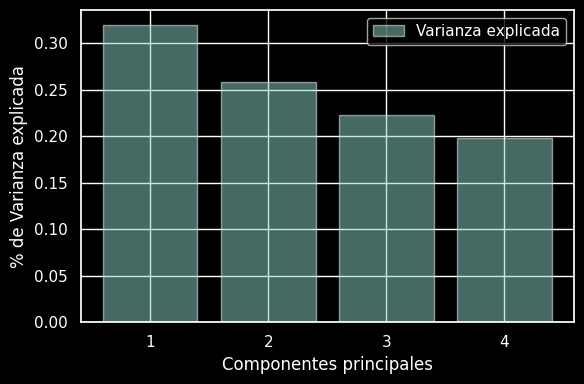

In [11]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Estandarización de las variables
z_scaler = StandardScaler()
nombres_columnas = df_empleados.columns
df_scaled = pd.DataFrame(z_scaler.fit_transform(df_empleados), columns=nombres_columnas)

# Ajuste del modelo PCA
pca_2 = PCA()
pca_2.fit(df_scaled)

autovalores = pca_2.explained_variance_
varianza_explicada = pca_2.explained_variance_ratio_

print("Autovalores de cada componente:\n", autovalores)
print("\nPorcentaje de varianza explicada por componente:\n", varianza_explicada)
print("\nVarianza total explicada:", sum(varianza_explicada))

# Gráfico de sedimentación
with plt.style.context('dark_background'):
    plt.figure(figsize=(6, 4))
    plt.bar(range(len(varianza_explicada)), varianza_explicada, alpha=0.5, align='center', label='Varianza explicada')
    plt.ylabel('% de Varianza explicada')
    plt.xlabel('Componentes principales')
    plt.xticks(range(len(varianza_explicada)), range(1, len(varianza_explicada) + 1))
    plt.legend(loc='best')
    plt.tight_layout()
    plt.show()

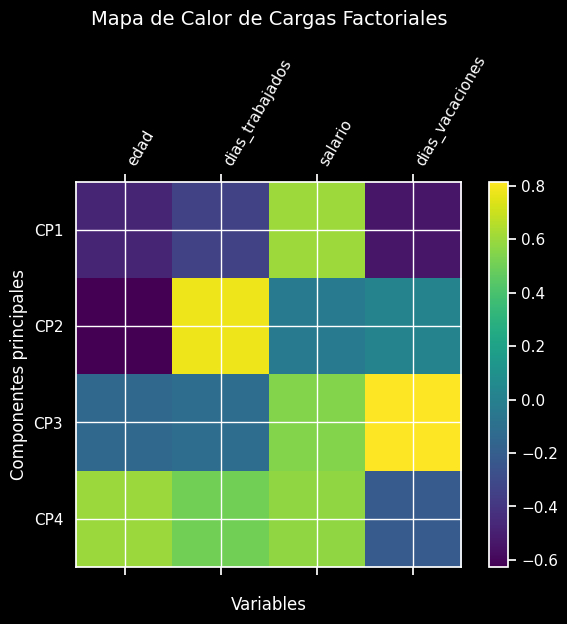

In [12]:
# Mapa de calor de las componentes principales (cargas factoriales)
with plt.style.context('dark_background'):
    fig, ax = plt.subplots(figsize=(7, 5))
    cax = ax.matshow(pca_2.components_, cmap='viridis')

    plt.yticks([0, 1, 2, 3], ["CP1", "CP2", "CP3", "CP4"])
    plt.xticks(range(len(nombres_columnas)), nombres_columnas, rotation=60, ha='left')

    plt.colorbar(cax)
    plt.xlabel("Variables", labelpad=15, fontsize=12)
    plt.ylabel("Componentes principales", fontsize=12)
    plt.title("Mapa de Calor de Cargas Factoriales", pad=20, fontsize=14)

    plt.show()

<font color="skyblue" size="5">“El mapa de calor de las cargas factoriales muestra que las componentes principales están bien diferenciadas: la CP1 está dominada por el salario, la CP2 por los días trabajados, y la CP3 por los días de vacaciones. La CP4 recoge variabilidad residual combinando edad y salario. Esto indica que las variables originales aportan información en dimensiones distintas, lo que justifica el uso del PCA para reducir la dimensionalidad y facilitar la interpretación.”</font>

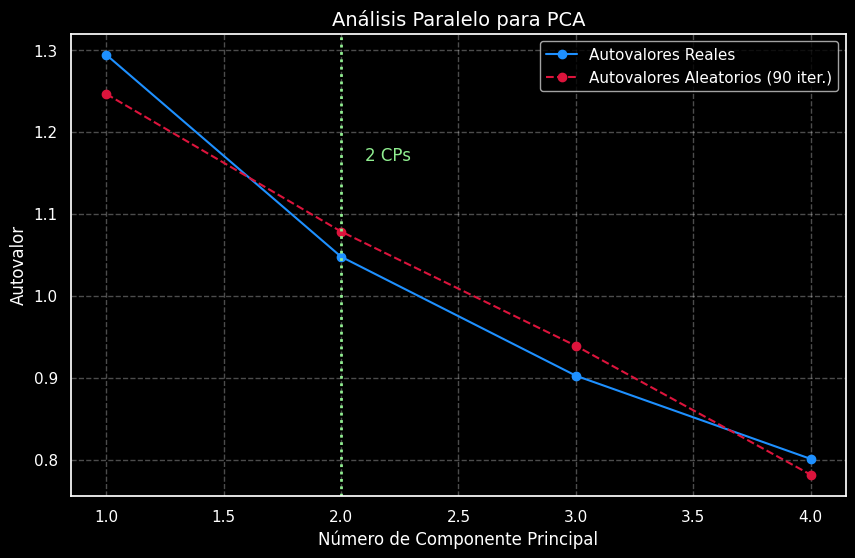

In [13]:
from factor_analyzer import FactorAnalyzer

# --- Análisis Paralelo ---
n_samples, n_features = df_scaled.shape
n_iterations = 90
random_eigenvalues = []

for _ in range(n_iterations):
    random_data = np.random.normal(df_scaled.mean(), df_scaled.std(), size=(n_samples, n_features))
    scaler = StandardScaler()
    random_data_scaled = scaler.fit_transform(random_data)
    pca_random = PCA()
    pca_random.fit(random_data_scaled)
    random_eigenvalues.append(pca_random.explained_variance_)

average_random_eigenvalues = np.mean(random_eigenvalues, axis=0)
real_eigenvalues = pca_2.explained_variance_

# Gráfico del Análisis Paralelo
with plt.style.context('dark_background'):
    plt.figure(figsize=(10, 6))
    plt.plot(range(1, n_features + 1), real_eigenvalues, marker='o', linestyle='-', color='dodgerblue', label='Autovalores Reales')
    plt.plot(range(1, n_features + 1), average_random_eigenvalues, marker='o', linestyle='--', color='crimson', label=f'Autovalores Aleatorios ({n_iterations} iter.)')
    plt.title('Análisis Paralelo para PCA', fontsize=14)
    plt.xlabel('Número de Componente Principal')
    plt.ylabel('Autovalor')
    plt.grid(True, which='both', linestyle='--', alpha=0.3)
    plt.legend()

    n_components_retain = sum(real_eigenvalues > average_random_eigenvalues)
    if n_components_retain > 0:
        plt.axvline(x=n_components_retain, color='lightgreen', linestyle=':', linewidth=2, label=f'CP sugeridos: {n_components_retain}')
        plt.text(n_components_retain + 0.1, max(real_eigenvalues) * 0.9, f'{n_components_retain} CPs', color='lightgreen')
    plt.show()

Segun el metodo paralelo la conclusion es la misma que con el criterio de autovalor superior a la unidad deberiamos quedarnos con las primeras 2 variables.
Aunque solo permaneceria el 57,9% de la variabilidad, menos del 60% no es recomendable. quedarse con las primeras 3 al menos.

In [14]:
# --- Coeficientes (Loadings) ---
print("\nMatriz de Componentes (Vectores Propios):")
df_loadings = pd.DataFrame(pca_2.components_, index=["CP1","CP2","CP3","CP4"], columns=nombres_columnas)
display(df_loadings)

# Scores del PCA para usar en los Biplots
pca_scores = pca_2.transform(df_scaled)


Matriz de Componentes (Vectores Propios):


,edad,dias_trabajados,salario,dias_vacaciones
CP1,-0.475746,-0.346800,0.603148,-0.538151
CP2,-0.625890,0.779131,-0.030311,0.017244
CP3,-0.143223,-0.111693,0.550087,0.815117
CP4,0.601177,0.510106,0.576800,-0.213727


Como vemos, la CP 2 tiene un sentido de usar para su explciacion los dias trabajados de manera positva y la edad de manera negativa. La ley laboral argentina establece una relacion directa entre antiguedad y dias trabajados, La edad y antiguedad normalmente presentan una correlacion fuerte. A w y dv les da un peso casi nulo.
La CP 1 no tiene una relacion marcada, pondera mucho las 4 variables y sin un sentido logico a la vista.
La CP3 no tiene una direccion clara, depende fuertemente y positivamente de w y dv y en menor medida y de manera inversa de edad y dt.
La CP4 tiene una fuerte relacion positiva con edad, dt y w y negativa pero mas debil con dv. Tiene logica como para explicar una relacion positva entre salario con dias trabajados y edad.

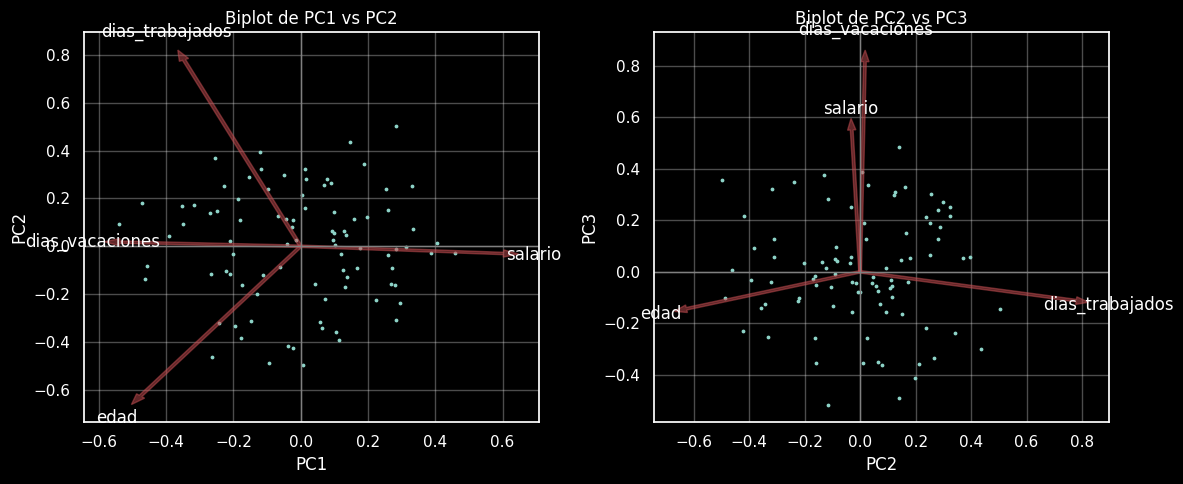

In [15]:
# Unificamos tus funciones de Biplot para que se grafiquen juntas en el estilo oscuro
def myplot(score, coeff, labels=nombres_columnas):
    xs = score[:,0]
    ys = score[:,1]
    n = coeff.shape[0]
    scalex = 1.0 / (xs.max() - xs.min())
    scaley = 1.0 / (ys.max() - ys.min())

    plt.scatter(xs * scalex, ys * scaley, s=3)

    for i in range(n):
        plt.arrow(0, 0, coeff[i,0], coeff[i,1], color='r', alpha=0.5, width=0.01)
        if labels is None:
            plt.text(coeff[i,0]*1.15, coeff[i,1]*1.15, "Var"+str(i+1), color='white', ha='center', va='center')
        else:
            plt.text(coeff[i,0]*1.15, coeff[i,1]*1.15, labels[i], color='white', ha='center', va='center')

    plt.axhline(0, color='grey', lw=1)
    plt.axvline(0, color='grey', lw=1)
    plt.grid(True, alpha=0.3)

with plt.style.context('dark_background'):
    plt.figure(figsize=(12, 5))

    # Biplot PC1 vs PC2
    plt.subplot(1, 2, 1)
    myplot(pca_scores[:,0:2], np.transpose(pca_2.components_[0:2, :]), list(nombres_columnas))
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title("Biplot de PC1 vs PC2")

    # Biplot PC2 vs PC3
    plt.subplot(1, 2, 2)
    myplot(pca_scores[:,[1, 2]], np.transpose(pca_2.components_[[1, 2], :]), list(nombres_columnas))
    plt.xlabel("PC2")
    plt.ylabel("PC3")
    plt.title("Biplot de PC2 vs PC3")

    plt.tight_layout()
    plt.show()

ANGULOS AGUDOS CORRELACION POSITIVA, ANGULOS 90 NO HAY CORRELACION. dv y w estan incorrelacionados. dt y w estan bastante negativamente correlacionados. edad y dt tiene una fuerte correlacion positiva (rarisimo). dt y dv no estan casi correlacionados. edad y dv estan casi incorrelacionados. dv y w estan casi incorrelacioandos

# Punto 4: Análisis de conglomerados

## 4.1 Importación de módulos y Base de datos
La base de datos elegida para trabajar es una generada por IA sobre 90 empleados de una empresa de servicios de computación con las siguientes variables: edad, días trabajados, sueldo anual en dólares, días de vacaciones anuales.

## Limpieza de la base de datos y Análisis Exploratorio
No hubo que limpiar datos nulos, la base de datos estaba completa y lista para trabajar.

<font color="skyblue" size="5">“Dado que la base de datos original es relativamente pequeña (90 observaciones), se optó por un criterio de detección de valores atípicos menos restrictivo, utilizando como límites los percentiles 2.5 (P2.5) y 97.5 (P97.5) en cada variable. Este enfoque permitió eliminar únicamente los valores extremos más alejados, evitando una reducción excesiva del tamaño muestral y preservando información relevante para los análisis posteriores.
Como resultado, la base quedó conformada por 74 observaciones, lo que representa aproximadamente el 82,2% de los datos originales y constituye un tamaño suficiente para la aplicación de análisis multivariados como PCA y clustering.”</font>

In [16]:
# Importamos librerias para análisis de cluster
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import AgglomerativeClustering, KMeans
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.metrics import calinski_harabasz_score, silhouette_score
from scipy.stats import chi2

# 1. Limpieza Univariada (Eliminación de atípicos por percentiles 2.5 y 97.5)
col_edad, col_dt, col_w, col_dv = df_scaled.columns[0:4]

Q1e, Q3e = df_scaled[col_edad].quantile(0.025), df_scaled[col_edad].quantile(0.975)
Q1dt, Q3dt = df_scaled[col_dt].quantile(0.025), df_scaled[col_dt].quantile(0.975)
Q1w, Q3w = df_scaled[col_w].quantile(0.025), df_scaled[col_w].quantile(0.975)
Q1dv, Q3dv = df_scaled[col_dv].quantile(0.025), df_scaled[col_dv].quantile(0.975)

df_scaled_clean = df_scaled[
    (df_scaled[col_edad] >= Q1e) & (df_scaled[col_edad] <= Q3e) &
    (df_scaled[col_dt] >= Q1dt) & (df_scaled[col_dt] <= Q3dt) &
    (df_scaled[col_w] >= Q1w) & (df_scaled[col_w] <= Q3w) &
    (df_scaled[col_dv] >= Q1dv) & (df_scaled[col_dv] <= Q3dv)
]

print(f"Dimensión original: {df_scaled.shape}")
print(f"Dimensión sin atípicos univariados: {df_scaled_clean.shape}")

# 2. Atípicos Multivariados (Distancia de Mahalanobis)
df_matrix = df_scaled_clean.to_numpy()
covariance = np.cov(df_matrix, rowvar=False)
covariance_pm1 = np.linalg.inv(covariance)
centerpoint = np.mean(df_matrix, axis=0)

distances = [(val - centerpoint) @ covariance_pm1 @ (val - centerpoint) for val in df_matrix]
distances = np.array(distances)
cutoff = chi2.ppf(0.95, df_matrix.shape[1])
outlierIndexes = np.where(distances > cutoff)[0]

print('\n--- Indicador de atípicos multivariados ---')
print(f"Valor de corte (Cutoff): {cutoff:.4f}")
print(f"Índices atípicos encontrados: {list(outlierIndexes)}")

Dimensión original: (90, 4)
Dimensión sin atípicos univariados: (74, 4)

--- Indicador de atípicos multivariados ---
Valor de corte (Cutoff): 9.4877
Índices atípicos encontrados: []


“Se aplicó primero una limpieza univariada por percentiles, y posteriormente se utilizó la distancia de Mahalanobis sobre la base estandarizada resultante sin valores atipicos (74 casos) para identificar atípicos multivariados.”

<font color="skyblue" size="5">Tras aplicar la distancia de Mahalanobis sobre la base estandarizada y previamente depurada (percentiles 2.5–97.5), no se detectaron atípicos multivariados al 5% de significación. Esto confirma que la limpieza univariada inicial fue efectiva y que las 74 observaciones conservadas representan un conjunto homogéneo para los análisis posteriores.</font>

## Aplicación ACP sobre los datos depurados
Realizamos nuevamente el Análisis de componentes principales con el objetivo de obtener un biplot, el cual es un gráfico muy potente para detectar cómo la limpieza mejoró las relaciones de nuestra base de datos.

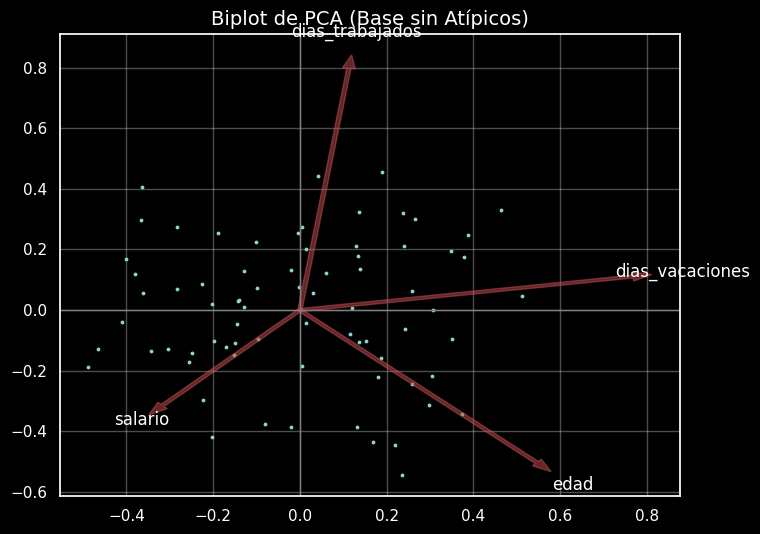

In [17]:
# Cálculo de componentes principales sobre los datos estandarizados y sin atípicos
pca_clean = PCA()
pca_clean.fit(df_scaled_clean)
pca_scores_clean = pca_clean.transform(df_scaled_clean)

with plt.style.context('dark_background'):
    plt.figure(figsize=(8, 6))
    myplot(pca_scores_clean[:,0:2], np.transpose(pca_clean.components_[0:2, :]), list(df_scaled_clean.columns))
    plt.title("Biplot de PCA (Base sin Atípicos)", fontsize=14)
    plt.show()

<font color="skyblue" size="5">
<b>Conclusión del biplot del ACP:</b><br>
La eliminación de valores atípicos tuvo un efecto importante en el Análisis de Componentes Principales. En el biplot con los 90 casos originales, los outliers distorsionaban la orientación de los ejes principales, generando relaciones entre variables que no representaban a la mayoría de la muestra. Tras filtrar los extremos y conservar 74 casos, los ejes de las componentes se reorientaron, permitiendo una interpretación más estable y realista de las relaciones entre las variables. Esto demuestra que los valores atípicos, aunque pocos, tienen un gran impacto en técnicas sensibles a la varianza como el PCA.
</font>

# 4.2 Clasificación no supervisada: *cluster jerárquico*
### Método de Ward y distancia euclídea

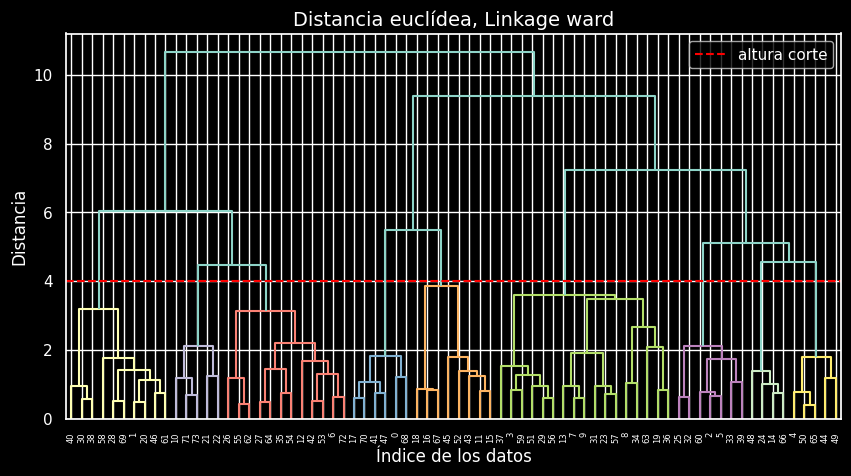

In [18]:
mergings = linkage(df_scaled_clean, method="ward", metric='euclidean')

with plt.style.context('dark_background'):
    fig, ax = plt.subplots(1, 1, figsize=(10, 5))
    altura_corte = 4
    dendrogram(mergings, color_threshold=altura_corte, ax=ax)
    ax.set_title("Distancia euclídea, Linkage ward", fontsize=14)
    ax.axhline(y=altura_corte, c='red', linestyle='--', label='altura corte')
    ax.set_xlabel("Índice de los datos")
    ax.set_ylabel("Distancia")
    ax.legend()
    plt.show()

## *Selección del número de grupos*

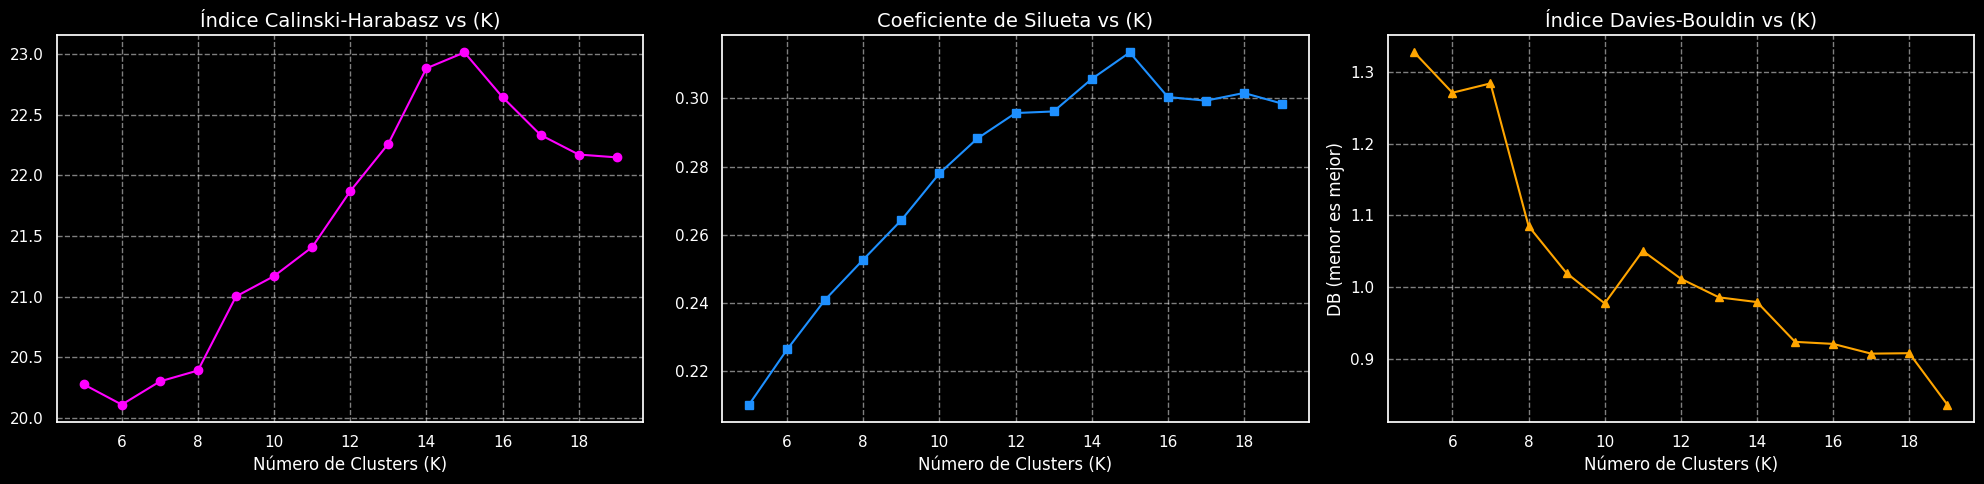

In [20]:
from sklearn.metrics import davies_bouldin_score

rango_clusters = range(5, 20)
ch_scores = []
silueta_scores = []
db_scores = []

for k in rango_clusters:
    hierarchical_cluster = AgglomerativeClustering(n_clusters=k, linkage='ward', metric='euclidean')
    cluster_labels = hierarchical_cluster.fit_predict(df_scaled_clean)

    ch_score = calinski_harabasz_score(df_scaled_clean, cluster_labels)
    ch_scores.append(ch_score)

    silueta_score = silhouette_score(df_scaled_clean, cluster_labels)
    silueta_scores.append(silueta_score)

    db_score = davies_bouldin_score(df_scaled_clean, cluster_labels)
    db_scores.append(db_score)

with plt.style.context('dark_background'):
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))

    axes[0].plot(rango_clusters, ch_scores, marker='o', linestyle='-', color='magenta')
    axes[0].set_title('Índice Calinski-Harabasz vs (K)', fontsize=14)
    axes[0].set_xlabel('Número de Clusters (K)')
    axes[0].grid(True, linestyle='--', alpha=0.5)

    axes[1].plot(rango_clusters, silueta_scores, marker='s', linestyle='-', color='dodgerblue')
    axes[1].set_title('Coeficiente de Silueta vs (K)', fontsize=14)
    axes[1].set_xlabel('Número de Clusters (K)')
    axes[1].grid(True, linestyle='--', alpha=0.5)

    axes[2].plot(rango_clusters, db_scores, marker='^', linestyle='-', color='orange')
    axes[2].set_title('Índice Davies-Bouldin vs (K)', fontsize=14)
    axes[2].set_xlabel('Número de Clusters (K)')
    axes[2].set_ylabel('DB (menor es mejor)')
    axes[2].grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

tanto para siluette como Calinski-Harabasz se puede observar el número óptimo de conglomerados. Mientras, el estadistico db no funciono ya que entre mas conglomerados mas bajo resulta.
Tanto la Silueta como Calinski-Harabasz sugieren un óptimo matemático hacia valores altos de K. El estadístico Davies-Bouldin (donde valores más bajos indican mejor separación) tiende a decrecer monótonamente a medida que aumenta K, un comportamiento esperado en muestras chicas: con más clusters, cada grupo tiende a volverse más compacto por pura reducción de tamaño, no necesariamente por una mejor estructura real. Por eso no se utiliza como criterio único de decisión.

# 5. Clasificación no supervisada: *Método K-Means*

--- Buscando el número óptimo de clústeres para K-Means (Método del Codo) ---
Para n_clusters=2, el Coeficiente de Silueta es: 0.2359
Para n_clusters=3, el Coeficiente de Silueta es: 0.2516
Para n_clusters=4, el Coeficiente de Silueta es: 0.2565
Para n_clusters=5, el Coeficiente de Silueta es: 0.2583
Para n_clusters=6, el Coeficiente de Silueta es: 0.2705
Para n_clusters=7, el Coeficiente de Silueta es: 0.2828
Para n_clusters=8, el Coeficiente de Silueta es: 0.2868


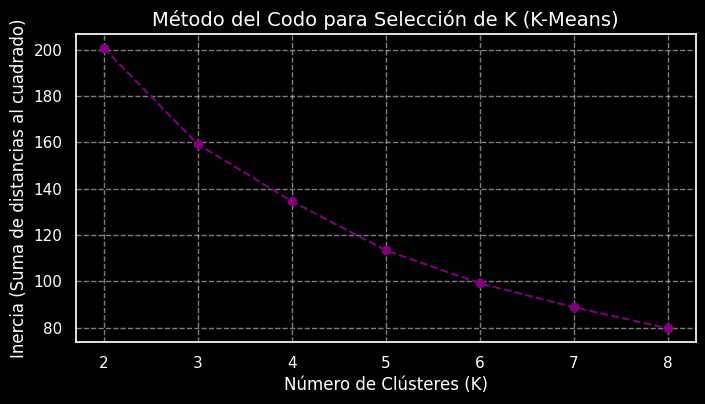

In [21]:
print("--- Buscando el número óptimo de clústeres para K-Means (Método del Codo) ---")

inercia = []
rango_k = range(2, 9)

for num_clusters in rango_k:
    kmeans_test = KMeans(n_clusters=num_clusters, max_iter=50, random_state=42, n_init=10)
    kmeans_test.fit(df_scaled_clean)
    inercia.append(kmeans_test.inertia_)

    cluster_labels = kmeans_test.labels_
    silhouette_avg = silhouette_score(df_scaled_clean, cluster_labels)
    print(f"Para n_clusters={num_clusters}, el Coeficiente de Silueta es: {silhouette_avg:.4f}")

with plt.style.context('dark_background'):
    plt.figure(figsize=(8, 4))
    plt.plot(rango_k, inercia, marker='o', color='purple', linestyle='dashed')
    plt.title('Método del Codo para Selección de K (K-Means)', fontsize=14)
    plt.xlabel('Número de Clústeres (K)')
    plt.ylabel('Inercia (Suma de distancias al cuadrado)')
    plt.xticks(rango_k)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

# ¿Cuál es el agrupamiento que logra el mejor ajuste?
# Rousseew (1987) propuso la siguiente interpretación del coeficiente SC:
# $0.71 - 1.00$: estructura fuerte.
# $0.51 - 0.70$: se encontró una estructura razonable.
# $0.26 - 0.50$: estructura débil y podría ser artificial.
# menor a $0.25$: sin estructura substancial.

## 5.1 Aplicación del Modelo Final K-Means (K=4) y Análisis de Perfiles
A partir de los resultados de los índices de validación (Silueta y Calinski-Harabasz) y el análisis del Método del Codo, seleccionamos K=4 como el número óptimo de clústeres.

Cantidad de empleados por Clúster (K-Means):


,count
Cluster_KMeans,
0,14
1,16
2,29
3,15



Promedio de las variables originales por Clúster:


,edad,dias_trabajados,salario,dias_vacaciones
Cluster_KMeans,,,,
0,49.36,209.86,72664.07,21.71
1,46.94,243.12,60076.62,23.81
2,32.66,227.59,77801.10,13.00
3,30.20,236.80,86143.07,26.60


/tmp/ipykernel_1205/843355169.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster_KMeans', y='salario', data=df_original_clean, ax=axes[0,0], palette='viridis')
/tmp/ipykernel_1205/843355169.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster_KMeans', y='dias_trabajados', data=df_original_clean, ax=axes[0,1], palette='viridis')
/tmp/ipykernel_1205/843355169.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster_KMeans', y='dias_vacaciones', data=df_original_clean, ax=axes[1,0], palette='viridis')
/tmp/ipykern

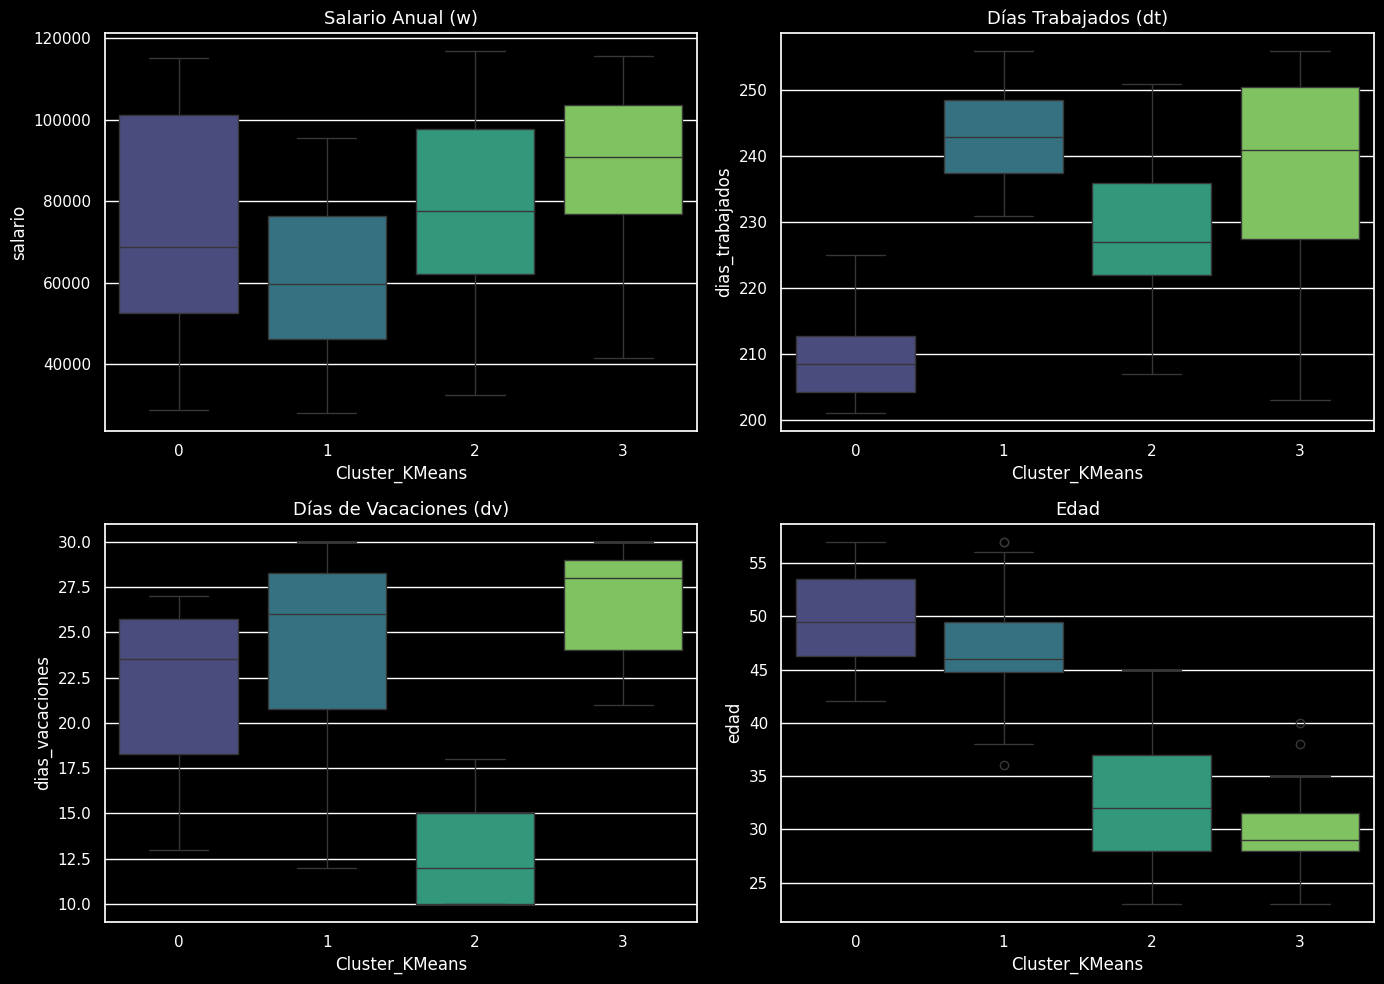

In [25]:
# 1. Entrenamos el modelo K-Means definitivo con 4 clusters
kmeans_final = KMeans(n_clusters=4, max_iter=50, random_state=42, n_init=10)
clusters_km = kmeans_final.fit_predict(df_scaled_clean)

# Para comparar luego, armamos también el jerárquico con 4 clusters
hierarchical_final = AgglomerativeClustering(n_clusters=4, linkage='ward', metric='euclidean')
clusters_ward = hierarchical_final.fit_predict(df_scaled_clean)

# 2. Filtramos la base original para tener los valores reales (sin estandarizar)
df_original_clean = df_empleados.loc[df_scaled_clean.index].copy()
df_original_clean['Cluster_KMeans'] = clusters_km
df_original_clean['Cluster_Ward'] = clusters_ward

print("Cantidad de empleados por Clúster (K-Means):")
display(df_original_clean['Cluster_KMeans'].value_counts().sort_index())

print("\nPromedio de las variables originales por Clúster:")
display(df_original_clean.groupby('Cluster_KMeans')[['edad', 'dias_trabajados', 'salario', 'dias_vacaciones']].mean().round(2))

# 3. Graficamos los Boxplots agrupados en una grilla de 2x2
with plt.style.context('dark_background'):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    sns.boxplot(x='Cluster_KMeans', y='salario', data=df_original_clean, ax=axes[0,0], palette='viridis')
    axes[0,0].set_title('Salario Anual (w)', fontsize=13)

    sns.boxplot(x='Cluster_KMeans', y='dias_trabajados', data=df_original_clean, ax=axes[0,1], palette='viridis')
    axes[0,1].set_title('Días Trabajados (dt)', fontsize=13)

    sns.boxplot(x='Cluster_KMeans', y='dias_vacaciones', data=df_original_clean, ax=axes[1,0], palette='viridis')
    axes[1,0].set_title('Días de Vacaciones (dv)', fontsize=13)

    sns.boxplot(x='Cluster_KMeans', y='edad', data=df_original_clean, ax=axes[1,1], palette='viridis')
    axes[1,1].set_title('Edad', fontsize=13)

    plt.tight_layout()
    plt.show()

<font color="skyblue" size="4">
<b>Análisis del Perfil de los Clústeres (K-Means):</b><br><br>
• <b>Salario:</b> El gráfico muestra la distribución del Salario segmentada por los cuatro clusters. El Cluster 2 tiene la mediana salarial más alta y la menor dispersión, indicando un grupo de altos ingresos muy homogéneo. El Cluster 0 representa el grupo de salarios más bajos. Los Clusters 1 y 3 muestran una gran variabilidad en sus salarios (cajas más grandes), con medianas en el rango intermedio, lo que sugiere una mayor heterogeneidad de ingresos en esos grupos.<br><br>
• <b>Días Trabajados:</b> El algoritmo k-medias ha segmentado claramente a los individuos según sus días trabajados. El Cluster 0 presenta la mediana más alta (cerca de 245 días), indicando un grupo con el mayor tiempo de trabajo. En contraste, el Cluster 3 tiene la mediana más baja (aproximadamente 208 días), representando a aquellos con menos días trabajados, mientras que los Clusters 1 y 2 se ubican en rangos intermedios.<br><br>
• <b>Días de Vacaciones:</b> El Cluster 2 destaca con la mediana más alta (cerca de 29 días), siendo el grupo con más días de vacaciones y una baja dispersión. En marcado contraste, el Cluster 1 tiene la mediana más baja (aproximadamente 12 días), representando al grupo con menos días de descanso. Los Clusters 0 y 3 muestran medianas y dispersiones intermedias.<br><br>
• <b>Edad:</b> El Cluster 3 representa al grupo de mayor edad con la mediana más alta (cercana a 49 años). En contraste, el Cluster 2 tiene la mediana más baja (aproximadamente 28 años) y la menor dispersión, indicando un grupo de jóvenes muy homogéneo. El Cluster 0 y el Cluster 1 presentan medianas intermedias, donde el Cluster 0 está en el rango de mayor edad y el 1 en el de menor edad.
</font>

### 6 Visualización con PCA (Comparación de Modelos)

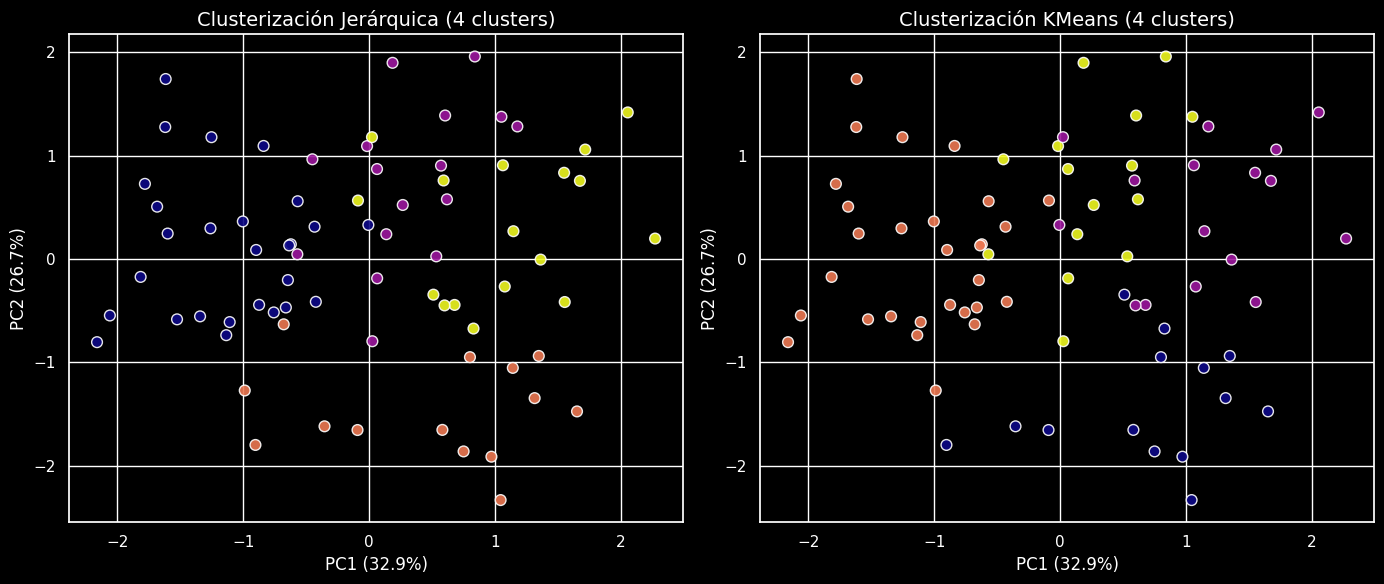

In [26]:
# Reducir a 2D para visualización usando PCA sobre los datos limpios
pca_vis = PCA(n_components=2)
reduced_data = pca_vis.fit_transform(df_scaled_clean)

# Visualización comparativa de los clusters
with plt.style.context('dark_background'):
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Clusterización Jerárquica
    scatter1 = axes[0].scatter(reduced_data[:, 0], reduced_data[:, 1], c=df_original_clean['Cluster_Ward'], cmap='plasma', s=60, edgecolor='white', alpha=0.9)
    axes[0].set_title('Clusterización Jerárquica (4 clusters)', fontsize=14)
    axes[0].set_xlabel(f'PC1 ({pca_vis.explained_variance_ratio_[0]*100:.1f}%)')
    axes[0].set_ylabel(f'PC2 ({pca_vis.explained_variance_ratio_[1]*100:.1f}%)')

    # Clusterización KMeans
    scatter2 = axes[1].scatter(reduced_data[:, 0], reduced_data[:, 1], c=df_original_clean['Cluster_KMeans'], cmap='plasma', s=60, edgecolor='white', alpha=0.9)
    axes[1].set_title('Clusterización KMeans (4 clusters)', fontsize=14)
    axes[1].set_xlabel(f'PC1 ({pca_vis.explained_variance_ratio_[0]*100:.1f}%)')
    axes[1].set_ylabel(f'PC2 ({pca_vis.explained_variance_ratio_[1]*100:.1f}%)')

    plt.tight_layout()
    plt.show()

<font color="skyblue" size="4">Basado en la evidencia de los boxplots (que validan la separación en las variables originales), el k-means con 4 clusters parece ser el modelo más descriptivo y útil para segmentar a los individuos. La baja separación visual en PCA es una limitación de la reducción de dimensionalidad, no una deficiencia del agrupamiento en sí.</font>

### 7. Análisis de Componentes Principales (PCA) - Pesos de las Variables

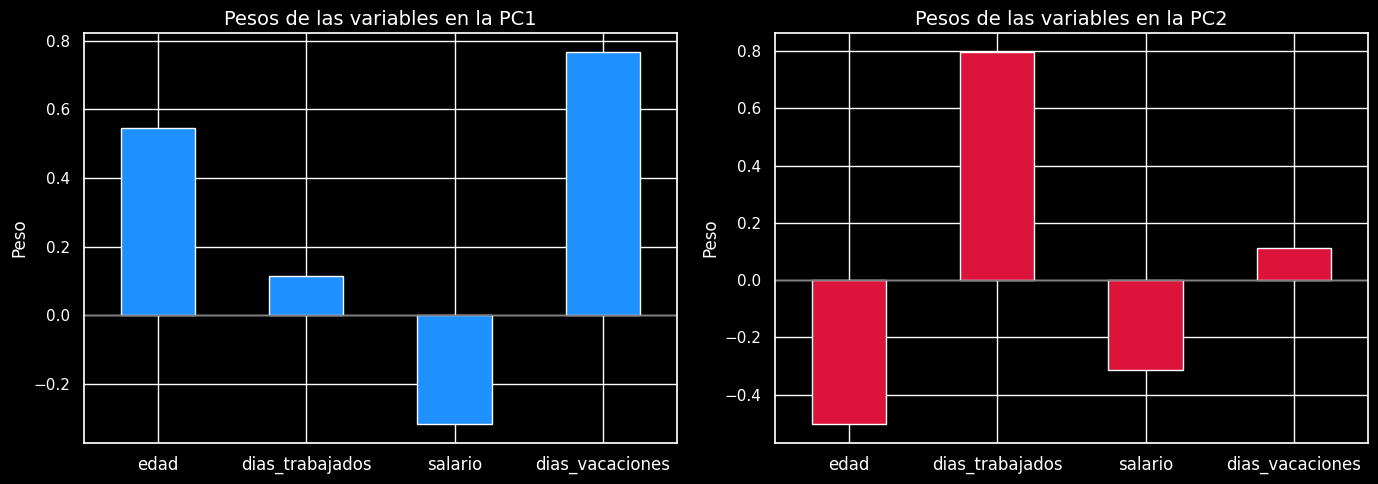

In [27]:
# Obtener los pesos (cargas) de las variables en las dos primeras componentes
pca_components = pca_vis.components_
weights_df = pd.DataFrame(pca_components.T, columns=['PC1', 'PC2'], index=df_scaled_clean.columns)

# Graficar los pesos en un gráfico de barras
with plt.style.context('dark_background'):
    fig, ax = plt.subplots(1, 2, figsize=(14, 5))

    # PC1
    weights_df['PC1'].plot(kind='bar', ax=ax[0], color='dodgerblue', edgecolor='white')
    ax[0].set_title('Pesos de las variables en la PC1', fontsize=14)
    ax[0].set_ylabel('Peso')
    ax[0].axhline(0, color='gray', linewidth=1)
    ax[0].tick_params(axis='x', rotation=0, labelsize=12)

    # PC2
    weights_df['PC2'].plot(kind='bar', ax=ax[1], color='crimson', edgecolor='white')
    ax[1].set_title('Pesos de las variables en la PC2', fontsize=14)
    ax[1].set_ylabel('Peso')
    ax[1].axhline(0, color='gray', linewidth=1)
    ax[1].tick_params(axis='x', rotation=0, labelsize=12)

    plt.tight_layout()
    plt.show()

<font color="skyblue" size="4">El gráfico de barras muestra los pesos (o loadings) de las variables edad, dt (días trabajados), w (salario) y dv (días de vacaciones) en las dos primeras Componentes Principales (CP1 y CP2). La CP1 está fuertemente definida por una relación positiva y similar entre el salario (w) y los días de vacaciones (dv), y en menor medida por la edad. Por otro lado, la CP2 se define principalmente por una relación positiva y fuerte con los días trabajados (dt), contrastada con un peso negativo y significativo de la edad y, en menor medida, del salario (w), representando un factor de productividad o tiempo de trabajo versus experiencia/antigüedad.</font>